<a href="https://colab.research.google.com/github/abeeraz379/Smartphone-Usage-Addiction-Analysis-/blob/main/Smartphone_Usage_%26_Addiction_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smartphone Usage & Addiction Analysis
- ABeer Al-Zebda | Data Analyst & Data Scientist

# Project Overview

- Data Link : https://www.kaggle.com/datasets/algozee/smartphone-usage-and-addiction-analysis-dataset

#Load and inspect data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
path='/content/drive/MyDrive/Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv'
df=pd.read_csv(path)
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


 # Types of column

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

- 6 object columns
- 6 float columns
- 4 int columns

#Clean Data

- number of columns : 16
- number of rows : 7500

## check duplicates

In [25]:
df.duplicated().sum()

np.int64(0)

## check Missing values

In [26]:
df.isna().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


## Missing value rate

In [30]:
df.isna().sum()/len(df)*100

,0
transaction_id,0.00
user_id,0.00
age,0.00
gender,0.00
daily_screen_time_hours,0.00
social_media_hours,0.00
gaming_hours,0.00
work_study_hours,0.00
sleep_hours,0.00
notifications_per_day,0.00


<Axes: >

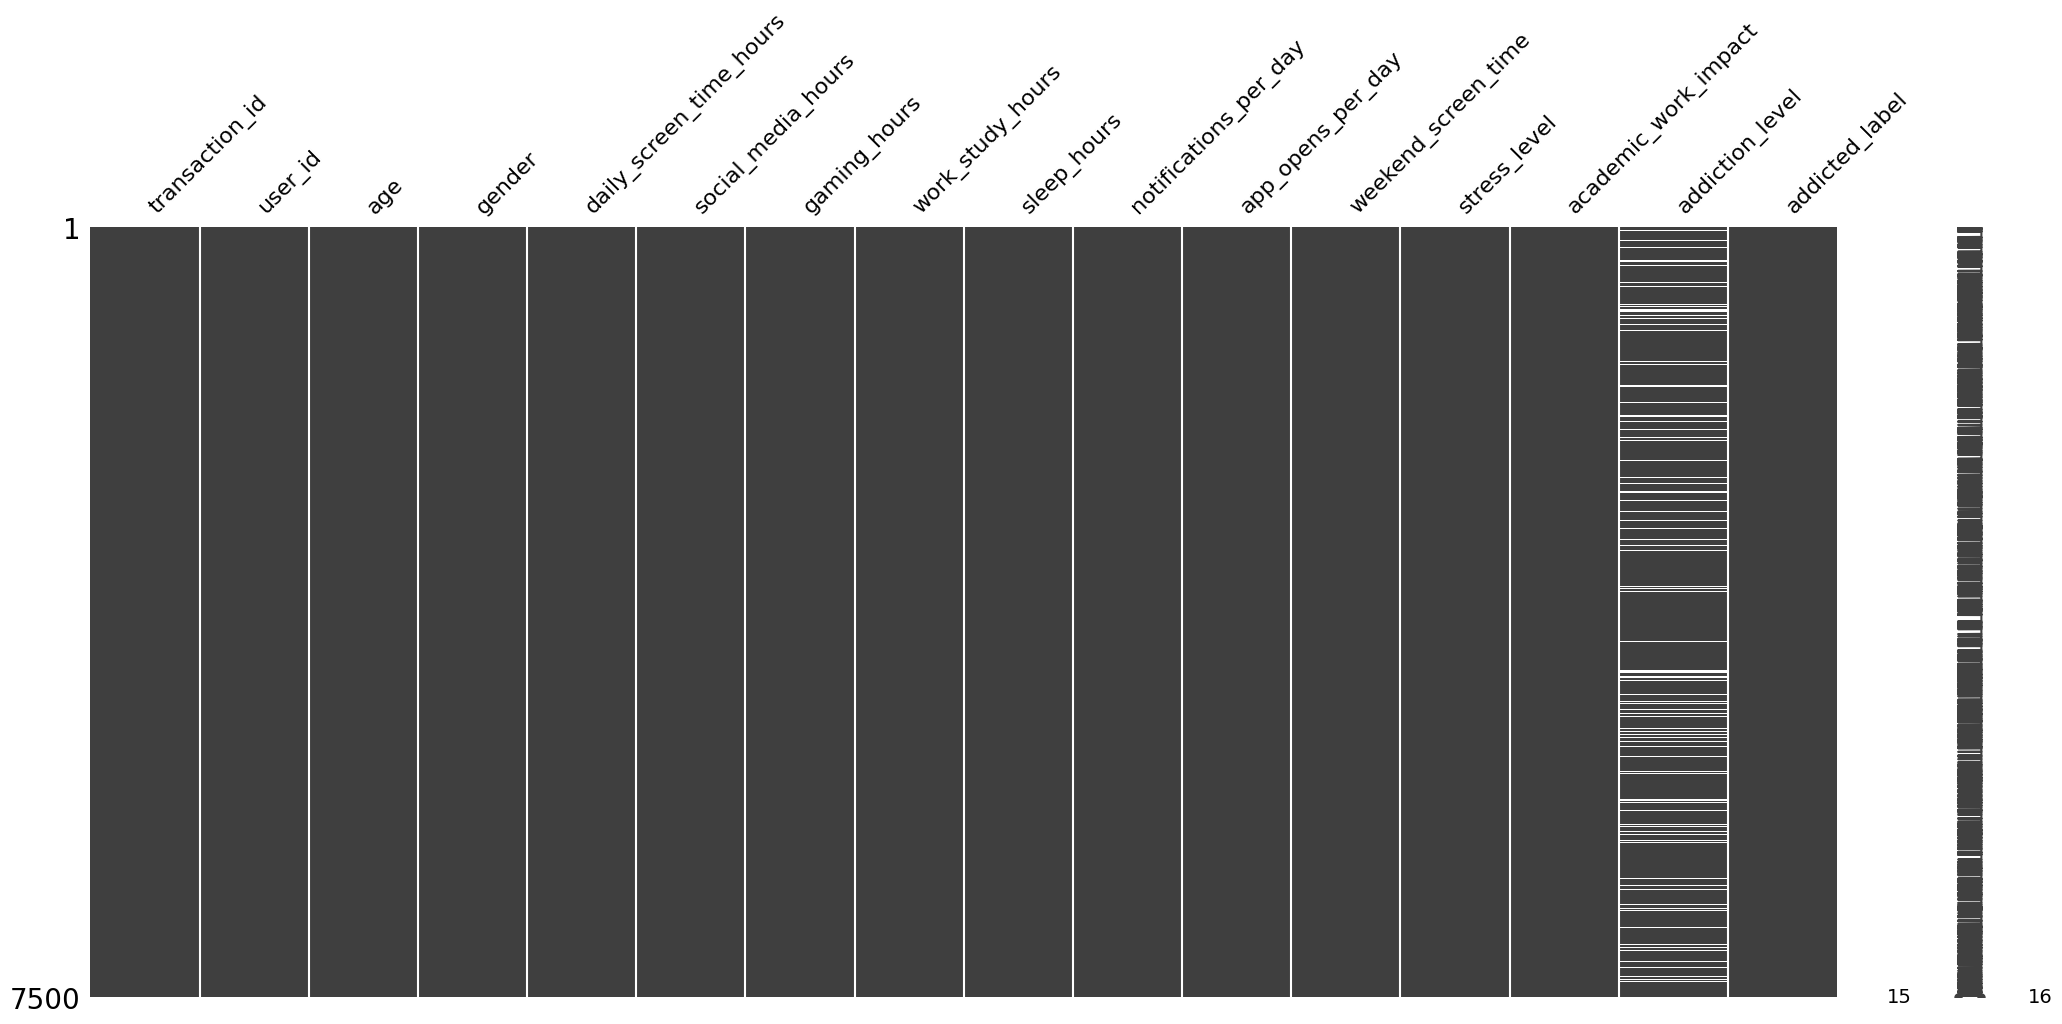

In [28]:
import missingno as msno
msno.matrix(df)

## check the value counts for column that has Missing value

In [34]:
df['addiction_level'].value_counts()

,count
addiction_level,
Moderate,2874
Severe,2434
Mild,1373


## drop the rows that have Missing values

In [31]:
df.dropna(subset=['addiction_level'], inplace=True)

## check for Missing after cleaning

In [32]:
df.isna().sum()

,0
transaction_id,0
user_id,0
age,0
gender,0
daily_screen_time_hours,0
social_media_hours,0
gaming_hours,0
work_study_hours,0
sleep_hours,0
notifications_per_day,0


<Axes: >

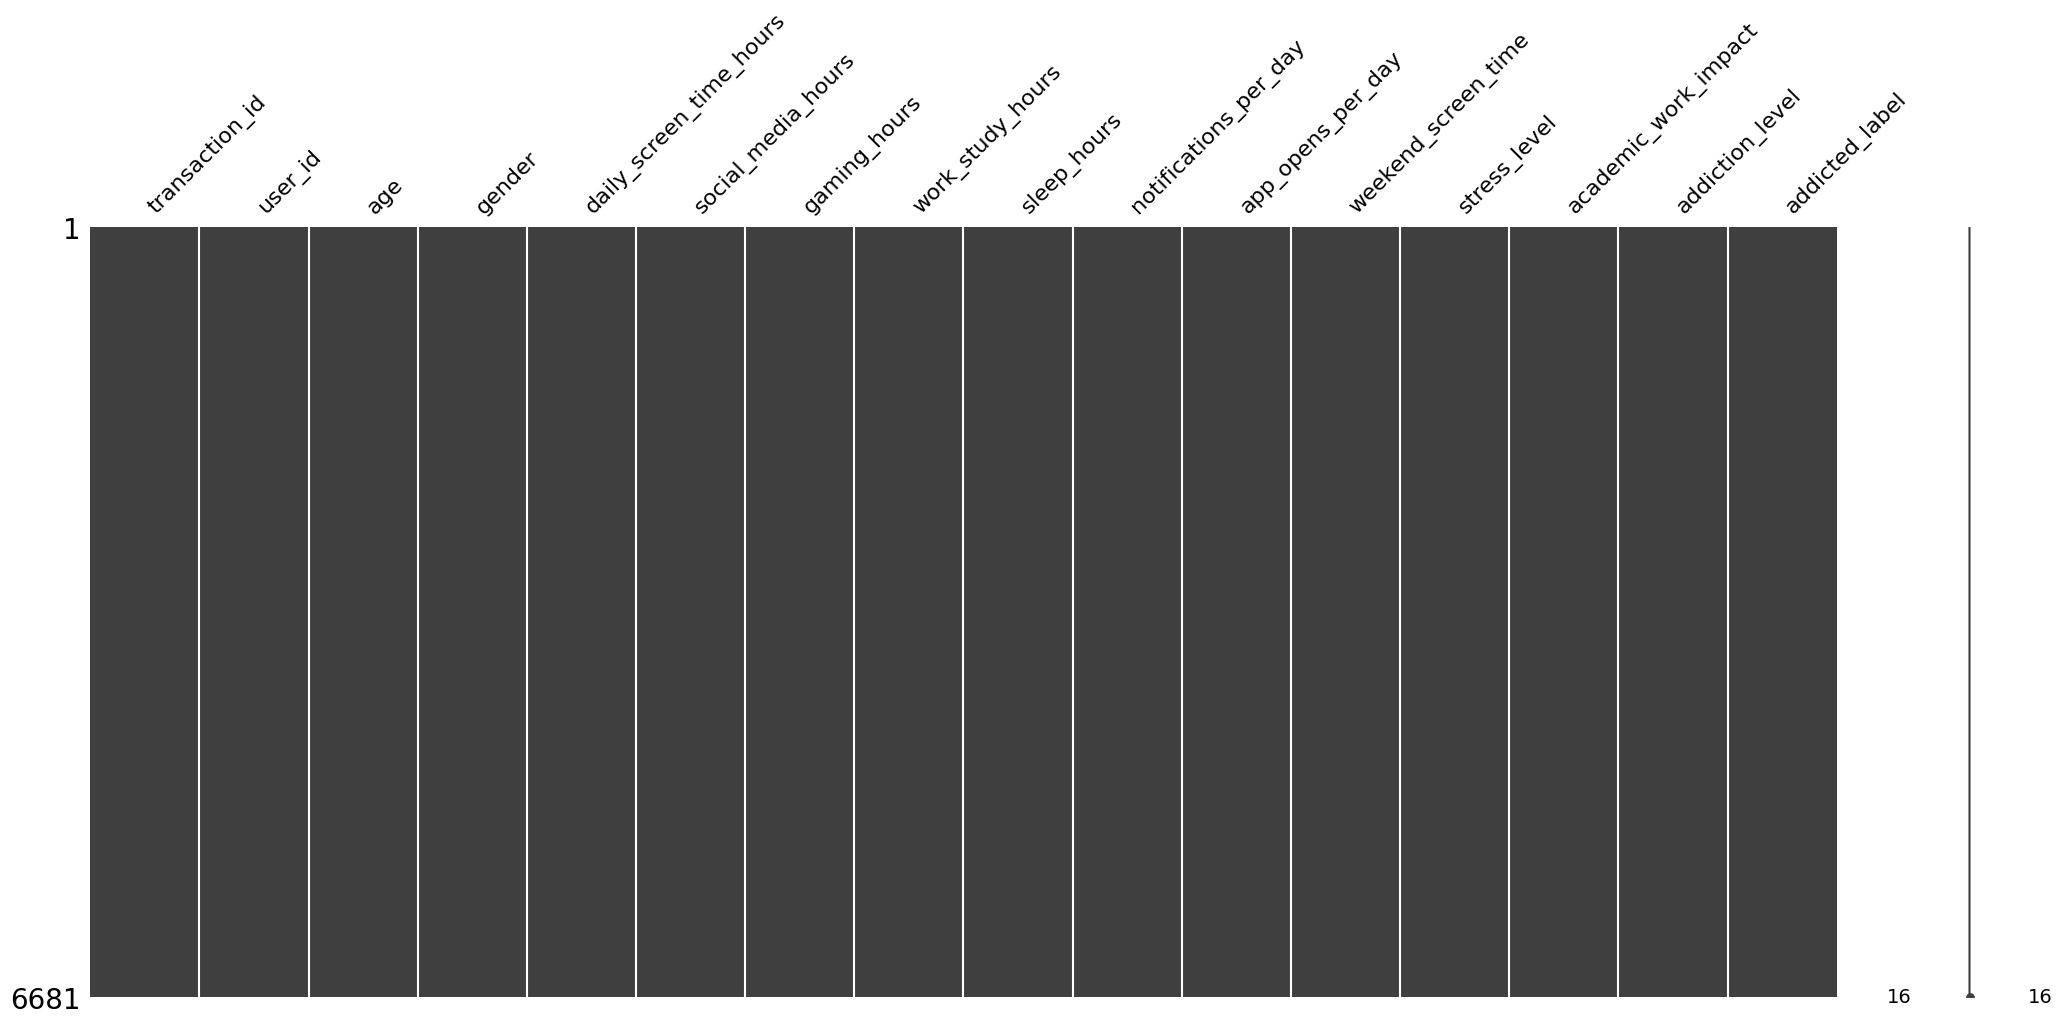

In [33]:
msno.matrix(df)

## check Consistancy

In [36]:
for x in df:
  print(df[x].value_counts())
  print('\n')

transaction_id
TXN07500    1
TXN00003    1
TXN00004    1
TXN00005    1
TXN00006    1
           ..
TXN00021    1
TXN00020    1
TXN00019    1
TXN00018    1
TXN00015    1
Name: count, Length: 6681, dtype: int64


user_id
U07500    1
U00003    1
U00004    1
U00005    1
U00006    1
         ..
U00021    1
U00020    1
U00019    1
U00018    1
U00015    1
Name: count, Length: 6681, dtype: int64


age
31    414
21    397
32    388
26    388
20    386
29    381
33    379
35    377
34    374
27    370
23    370
30    366
18    360
25    358
22    353
19    349
24    343
28    328
Name: count, dtype: int64


gender
Male      2284
Other     2214
Female    2183
Name: count, dtype: int64


daily_screen_time_hours
8.13     18
9.97     16
11.16    16
6.22     16
10.74    16
         ..
5.79      1
3.69      1
9.70      1
4.59      1
5.69      1
Name: count, Length: 898, dtype: int64


social_media_hours
5.81    23
5.03    23
5.35    22
3.07    22
5.80    22
        ..
0.50     5
3.79     4
2.01     4


#Exploratory Data Analysis

## Categorical Features

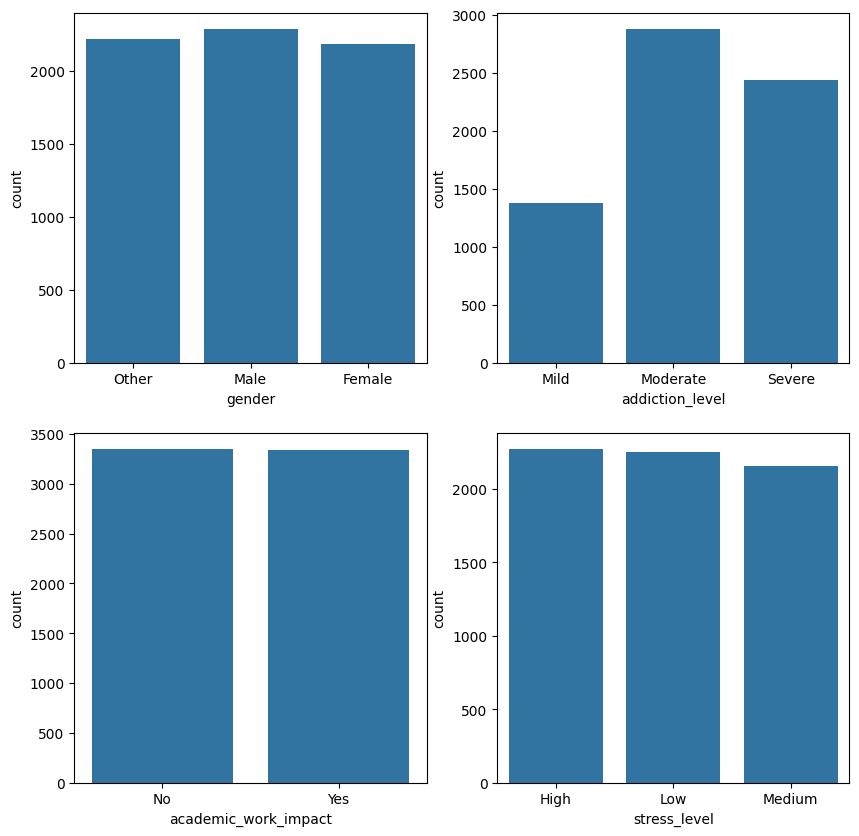

In [43]:
fig,ax=plt.subplots(ncols=2,nrows=2,figsize=(10,10))
ax[0][0]=sns.countplot(x='gender',data=df,ax=ax[0][0])
ax[0][1]=sns.countplot(x='addiction_level',data=df,ax=ax[0][1])
ax[1][0]=sns.countplot(x='academic_work_impact',data=df,ax=ax[1][0])
ax[1][1]=sns.countplot(x='stress_level',data=df,ax=ax[1][1]);


## numerical Features

<Axes: >

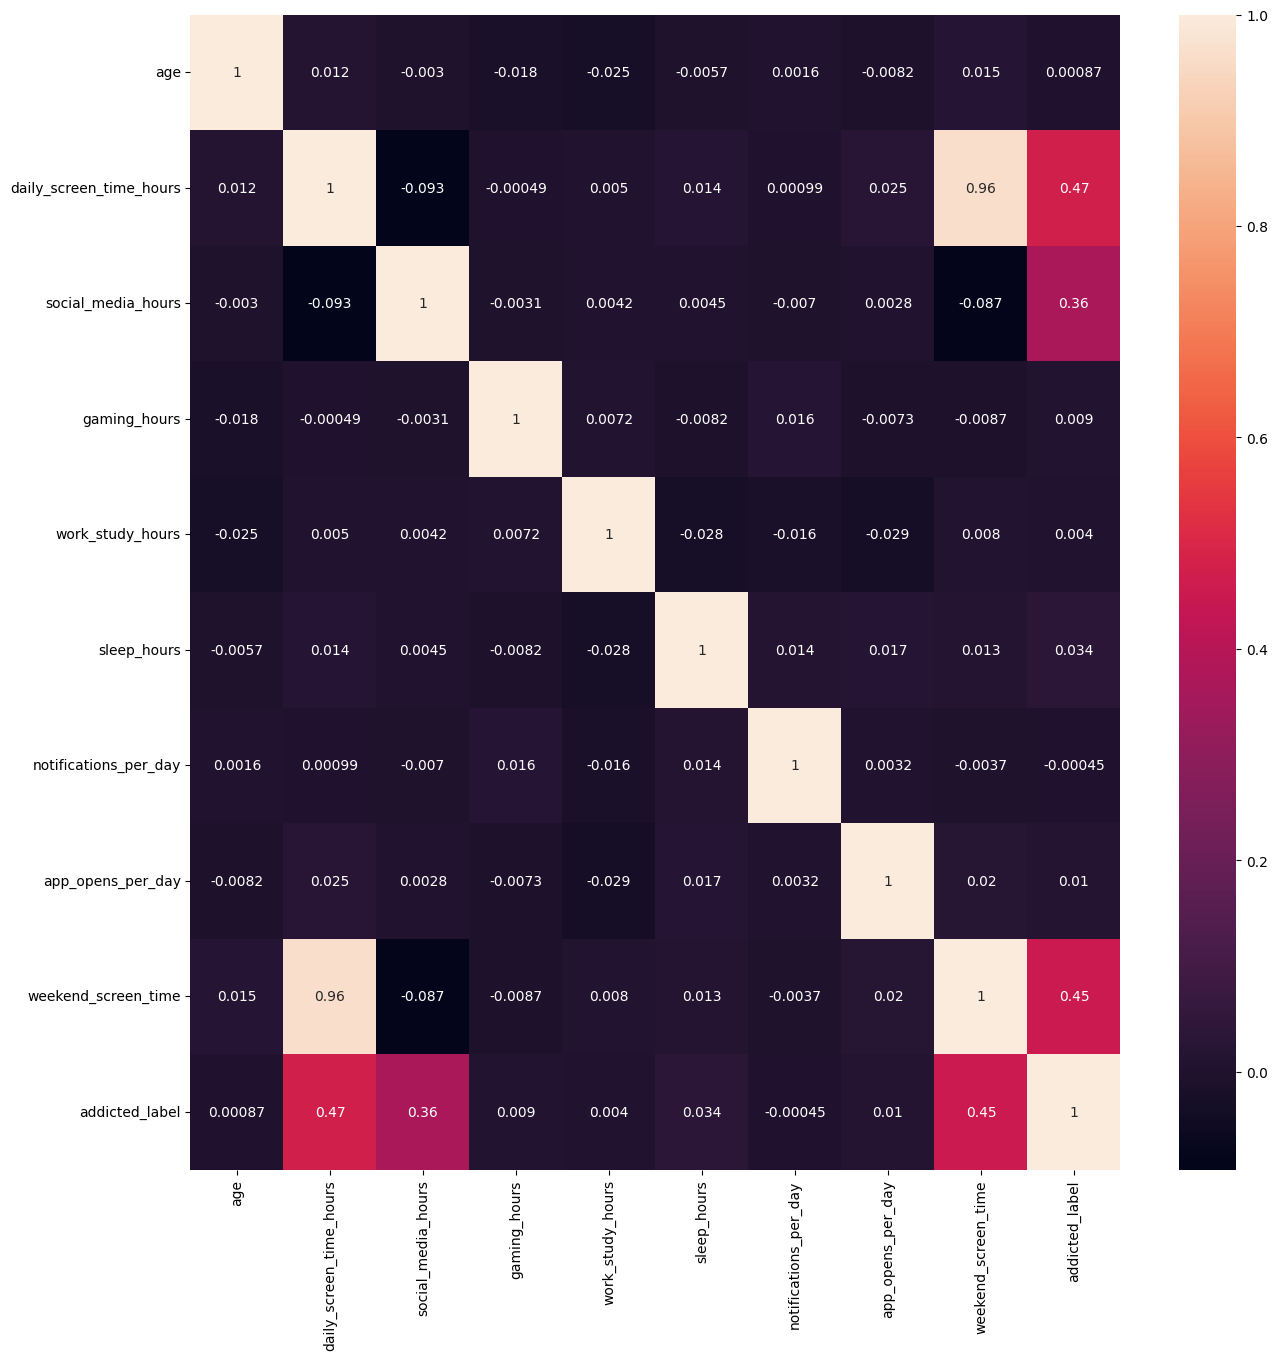

In [48]:
fig,ax=plt.subplots(figsize=(15,15))
crr=df.corr(numeric_only=True)
sns.heatmap(crr,annot=True)

#Future Inspection